## Here’s a step-by-step outline of the Thompson Sampling algorithm:

### Initialization Step:

Assign prior probability distributions to each arm’s expected reward (e.g., using beta distributions).

### Recurrence Step:

For each time step, repeat:

a. Sample from the posterior distributions of each arm (e.g., using beta distribution sampling after incorporating observed rewards).

b. Select the arm with the highest sample value (exploitation) and perform the corresponding action.

c. Observe the reward from the selected arm.

d. Update the posterior distribution of the selected arm using the observed reward (e.g., update the beta distribution parameters).

In Thompson Sampling, the main goal is to maximize rewards by balancing exploration (trying less-known options) and exploitation (choosing the option that has performed well so far). Here, we assume a binary reward outcome (success/failure) for simplicity.

* Starting with the basic binary reward model using Beta distributions (Beta(successes, failures)).
* Expanding later to contextual Thompson Sampling if you want to incorporate participant-level data (e.g., demographic info).
* Adding batch processing or parallel sampling if you scale to many participants.

In [ ]:
import random
from scipy.stats import beta

# Step 1: Initialize the conditions with priors
# Each condition (arm) starts with a Beta(1, 1) distribution, representing equal belief in success/failure.
# "successes" represents α (alpha) in Beta distribution: count of successes.
# "failures" represents β (beta) in Beta distribution: count of failures.
conditions = {
    "Condition_A": {"successes": 1, "failures": 1},  # Prior: Beta(1, 1)
    "Condition_B": {"successes": 1, "failures": 1}   # Prior: Beta(1, 1)
}

def thompson_sampling(conditions):
    """
    Perform Thompson Sampling to select a condition.

    Steps:
    1. Sample a success probability for each condition from its Beta distribution.
    2. Select the condition with the highest sampled probability.

    Args:
    - conditions (dict): Dictionary storing "successes" and "failures" for each condition.

    Returns:
    - str: The name of the selected condition.
    """
    best_condition = None
    max_sampled_value = -1  # Initialize the max sampled value to a very low number

    for condition, params in conditions.items():
        # Extract the current number of successes and failures for the condition
        successes = params['successes']
        failures = params['failures']

        # Sample a success probability from the Beta distribution Beta(successes, failures)
        # Beta distribution models the range of possible success probabilities for this condition.
        sampled_value = beta.rvs(successes, failures)

        # Compare sampled values and store the condition with the highest value
        if sampled_value > max_sampled_value:
            max_sampled_value = sampled_value
            best_condition = condition

    return best_condition

def log_outcome(condition, outcome):
    """
    Update the success or failure count for the chosen condition.

    Steps:
    1. If the outcome is a success (1), increment the "successes" count.
    2. If the outcome is a failure (0), increment the "failures" count.

    Args:
    - condition (str): The name of the condition to update.
    - outcome (int): The result of the condition (1 for success, 0 for failure).
    """
    if outcome == 1:  # Success
        conditions[condition]["successes"] += 1
    else:  # Failure
        conditions[condition]["failures"] += 1

# Step 2: Simulate Thompson Sampling with binary rewards
# Example: Simulate a scenario with "true" success probabilities for conditions
true_success_rates = {
    "Condition_A": 0.7,  # True success probability for Condition A
    "Condition_B": 0.5   # True success probability for Condition B
}

# Run 10 rounds of simulation
for i in range(10):
    # Choose a condition using Thompson Sampling
    chosen_condition = thompson_sampling(conditions)

    # Simulate the outcome based on the "true" success rate of the chosen condition
    outcome = 1 if random.random() < true_success_rates[chosen_condition] else 0

    # Log the outcome to update the Beta distribution for the chosen condition
    log_outcome(chosen_condition, outcome)

    # Print the current state of each condition for debugging and understanding
    print(f"Round {i + 1}:")
    print(f"  Chosen Condition: {chosen_condition}")
    print(f"  Outcome: {'Success' if outcome == 1 else 'Failure'}")
    print(f"  Updated Conditions: {conditions}\n")


Round 1:
  Chosen Condition: Condition_B
  Outcome: Failure
  Updated Conditions: {'Condition_A': {'successes': 1, 'failures': 1}, 'Condition_B': {'successes': 1, 'failures': 2}}

Round 2:
  Chosen Condition: Condition_A
  Outcome: Failure
  Updated Conditions: {'Condition_A': {'successes': 1, 'failures': 2}, 'Condition_B': {'successes': 1, 'failures': 2}}

Round 3:
  Chosen Condition: Condition_A
  Outcome: Success
  Updated Conditions: {'Condition_A': {'successes': 2, 'failures': 2}, 'Condition_B': {'successes': 1, 'failures': 2}}

Round 4:
  Chosen Condition: Condition_A
  Outcome: Failure
  Updated Conditions: {'Condition_A': {'successes': 2, 'failures': 3}, 'Condition_B': {'successes': 1, 'failures': 2}}

Round 5:
  Chosen Condition: Condition_A
  Outcome: Failure
  Updated Conditions: {'Condition_A': {'successes': 2, 'failures': 4}, 'Condition_B': {'successes': 1, 'failures': 2}}

Round 6:
  Chosen Condition: Condition_A
  Outcome: Success
  Updated Conditions: {'Condition_A': {'

Animation saved as 'Thompson_Sampling_Two_Conditions.gif'


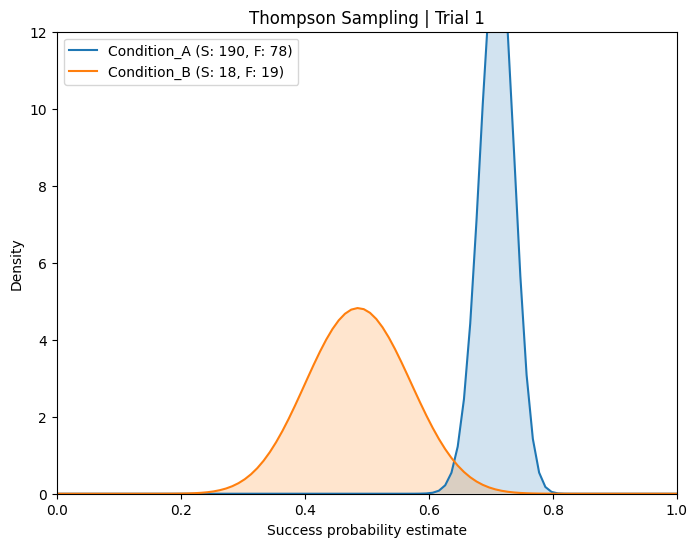

In [ ]:
import random
import numpy as np
from scipy.stats import beta
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML


# Step 1: Initialize the two conditions with Beta priors
# The Beta distribution for each condition starts as Beta(1, 1),
# which means "we know nothing" (flat/uniform prior).
conditions = {
    "Condition_A": {"successes": 1, "failures": 1},  # Beta(1, 1)
    "Condition_B": {"successes": 1, "failures": 1}   # Beta(1, 1)
}

# Step 2: Define the "true" success rates for simulation
# These are the "actual" success probabilities for the conditions in a real-world scenario.
# These values are unknown to the Thompson Sampling algorithm but used to simulate outcomes.
true_success_rates = {
    "Condition_A": 0.7,  # True success probability for Condition A
    "Condition_B": 0.5   # True success probability for Condition B
}

# Thompson Sampling implementation
def thompson_sampling(conditions):
    """
    Perform Thompson Sampling to select the best condition.

    Steps:
    1. For each condition, sample a success probability from its Beta(successes, failures) distribution.
       - The Beta distribution represents our current belief about the success probability of the condition.
    2. Select the condition with the highest sampled success probability.

    Returns:
    - str: The name of the selected condition.
    """
    best_condition = None
    max_sampled_value = -1

    for condition, params in conditions.items():
        # Sample a success probability from the Beta distribution
        # Math: The Beta distribution models P(success probability | observed data).
        # beta.rvs(successes, failures) generates a random sample (possible success probability).
        sampled_value = beta.rvs(params["successes"], params["failures"])

        # Track the condition with the highest sampled value
        if sampled_value > max_sampled_value:
            max_sampled_value = sampled_value
            best_condition = condition

    return best_condition

# Function to log the outcome of a trial
def log_outcome(condition, outcome):
    """
    Update the success or failure count for the selected condition.

    If the outcome is a success (1), increment the "successes" count for that condition.
    If the outcome is a failure (0), increment the "failures" count.

    This updates the Beta distribution parameters for the condition, incorporating the new data.

    Args:
    - condition (str): The name of the condition being updated.
    - outcome (int): The result of the trial (1 for success, 0 for failure).
    """
    if outcome == 1:
        # Increment the successes (alpha parameter of Beta distribution)
        conditions[condition]["successes"] += 1
    else:
        # Increment the failures (beta parameter of Beta distribution)
        conditions[condition]["failures"] += 1

# Visualization setup
fig, ax = plt.subplots(figsize=(8, 6))
x = np.linspace(0, 1, 100)  # Range of possible success probabilities (0 to 1)

def update_plot(frame):
    """
    Update the plot for each trial of Thompson Sampling.

    For each trial:
    1. Plot the Beta distribution for both conditions.
       - Math: The PDF of the Beta distribution shows the probability density
               of each possible success probability based on current data.
    2. Simulate a trial using Thompson Sampling.
    3. Log the outcome of the trial to update the distributions.

    Args:
    - frame (int): The current trial number (for labeling).
    """
    ax.clear()  # Clear the previous frame

    # Set plot title and axis labels
    ax.set_title(f"Thompson Sampling | Trial {frame + 1}")
    ax.set_xlabel("Success probability estimate")
    ax.set_ylabel("Density")
    ax.set_xlim(0, 1)  # Success probability is always between 0 and 1
    ax.set_ylim(0, 12)  # Set static y-limits for simplicity

    # Plot the Beta distributions for both conditions
    for condition, params in conditions.items():
        # Calculate the Beta PDF (probability density function)
        # Math: The PDF describes the likelihood of different success probabilities
        #       given the observed successes and failures.
        y = beta.pdf(x, params["successes"], params["failures"])

        # Plot the distribution
        ax.plot(x, y, label=f"{condition} (S: {params['successes']}, F: {params['failures']})")
        ax.fill_between(x, y, alpha=0.2)  # Add a filled region under the curve for visual clarity

    ax.legend()  # Add a legend to label the conditions

    # Simulate a round using Thompson Sampling
    chosen_condition = thompson_sampling(conditions)

    # Simulate an outcome for the chosen condition
    # Math: The outcome is randomly generated based on the "true" success rate
    #       of the chosen condition (not known to Thompson Sampling).
    outcome = 1 if random.random() < true_success_rates[chosen_condition] else 0

    # Log the outcome to update the Beta distribution parameters
    log_outcome(chosen_condition, outcome)

# Create the animation
num_trials = 300  # Number of trials (iterations of Thompson Sampling)
ani = animation.FuncAnimation(fig, update_plot, frames=num_trials, repeat=False)

# Save the animation as a GIF
ani.save("Thompson_Sampling_Two_Conditions.gif", writer="pillow", fps=10)
print("Animation saved as 'Thompson_Sampling_Two_Conditions.gif'")

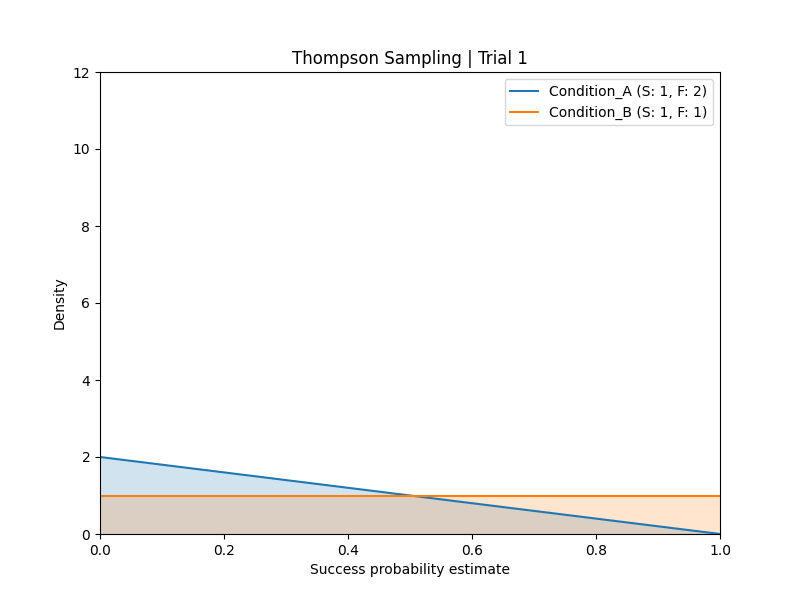

In [ ]:
from IPython.display import Image, display

# Display the GIF in the notebook
display(Image("Thompson_Sampling_Two_Conditions.gif"))

Animation saved as 'Thompson_Sampling_Two_Conditions_Equal.gif'


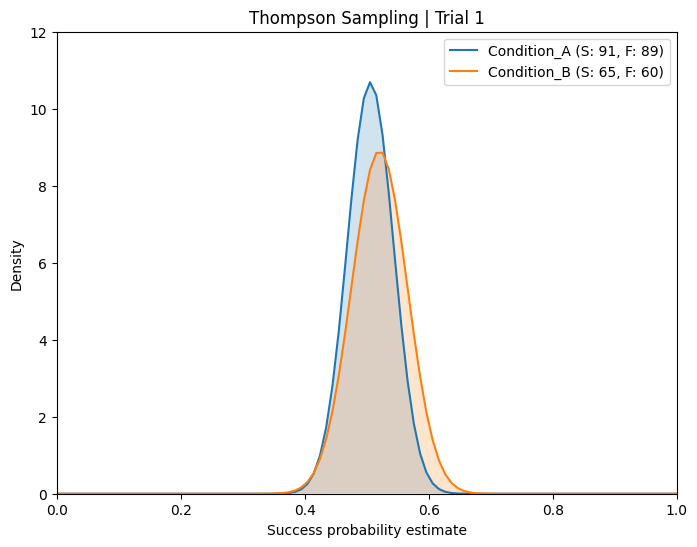

In [ ]:
import random
import numpy as np
from scipy.stats import beta
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML


# Step 1: Initialize the two conditions with Beta priors
# The Beta distribution for each condition starts as Beta(1, 1),
# which means "we know nothing" (flat/uniform prior).
conditions = {
    "Condition_A": {"successes": 1, "failures": 1},  # Beta(1, 1)
    "Condition_B": {"successes": 1, "failures": 1}   # Beta(1, 1)
}

# Step 2: Define the "true" success rates for simulation
# These are the "actual" success probabilities for the conditions in a real-world scenario.
# These values are unknown to the Thompson Sampling algorithm but used to simulate outcomes.
true_success_rates = {
    "Condition_A": 0.5,  # True success probability for Condition A
    "Condition_B": 0.5   # True success probability for Condition B
}

# Thompson Sampling implementation
def thompson_sampling(conditions):
    """
    Perform Thompson Sampling to select the best condition.

    Steps:
    1. For each condition, sample a success probability from its Beta(successes, failures) distribution.
       - The Beta distribution represents our current belief about the success probability of the condition.
    2. Select the condition with the highest sampled success probability.

    Returns:
    - str: The name of the selected condition.
    """
    best_condition = None
    max_sampled_value = -1

    for condition, params in conditions.items():
        # Sample a success probability from the Beta distribution
        # Math: The Beta distribution models P(success probability | observed data).
        # beta.rvs(successes, failures) generates a random sample (possible success probability).
        sampled_value = beta.rvs(params["successes"], params["failures"])

        # Track the condition with the highest sampled value
        if sampled_value > max_sampled_value:
            max_sampled_value = sampled_value
            best_condition = condition

    return best_condition

# Function to log the outcome of a trial
def log_outcome(condition, outcome):
    """
    Update the success or failure count for the selected condition.

    If the outcome is a success (1), increment the "successes" count for that condition.
    If the outcome is a failure (0), increment the "failures" count.

    This updates the Beta distribution parameters for the condition, incorporating the new data.

    Args:
    - condition (str): The name of the condition being updated.
    - outcome (int): The result of the trial (1 for success, 0 for failure).
    """
    if outcome == 1:
        # Increment the successes (alpha parameter of Beta distribution)
        conditions[condition]["successes"] += 1
    else:
        # Increment the failures (beta parameter of Beta distribution)
        conditions[condition]["failures"] += 1

# Visualization setup
fig, ax = plt.subplots(figsize=(8, 6))
x = np.linspace(0, 1, 100)  # Range of possible success probabilities (0 to 1)

def update_plot(frame):
    """
    Update the plot for each trial of Thompson Sampling.

    For each trial:
    1. Plot the Beta distribution for both conditions.
       - Math: The PDF of the Beta distribution shows the probability density
               of each possible success probability based on current data.
    2. Simulate a trial using Thompson Sampling.
    3. Log the outcome of the trial to update the distributions.

    Args:
    - frame (int): The current trial number (for labeling).
    """
    ax.clear()  # Clear the previous frame

    # Set plot title and axis labels
    ax.set_title(f"Thompson Sampling | Trial {frame + 1}")
    ax.set_xlabel("Success probability estimate")
    ax.set_ylabel("Density")
    ax.set_xlim(0, 1)  # Success probability is always between 0 and 1
    ax.set_ylim(0, 12)  # Set static y-limits for simplicity

    # Plot the Beta distributions for both conditions
    for condition, params in conditions.items():
        # Calculate the Beta PDF (probability density function)
        # Math: The PDF describes the likelihood of different success probabilities
        #       given the observed successes and failures.
        y = beta.pdf(x, params["successes"], params["failures"])

        # Plot the distribution
        ax.plot(x, y, label=f"{condition} (S: {params['successes']}, F: {params['failures']})")
        ax.fill_between(x, y, alpha=0.2)  # Add a filled region under the curve for visual clarity

    ax.legend()  # Add a legend to label the conditions

    # Simulate a round using Thompson Sampling
    chosen_condition = thompson_sampling(conditions)

    # Simulate an outcome for the chosen condition
    # Math: The outcome is randomly generated based on the "true" success rate
    #       of the chosen condition (not known to Thompson Sampling).
    outcome = 1 if random.random() < true_success_rates[chosen_condition] else 0

    # Log the outcome to update the Beta distribution parameters
    log_outcome(chosen_condition, outcome)

# Create the animation
num_trials = 300  # Number of trials (iterations of Thompson Sampling)
ani = animation.FuncAnimation(fig, update_plot, frames=num_trials, repeat=False)

# Save the animation as a GIF
ani.save("Thompson_Sampling_Two_Conditions_Equal.gif", writer="pillow", fps=10)
print("Animation saved as 'Thompson_Sampling_Two_Conditions_Equal.gif'")

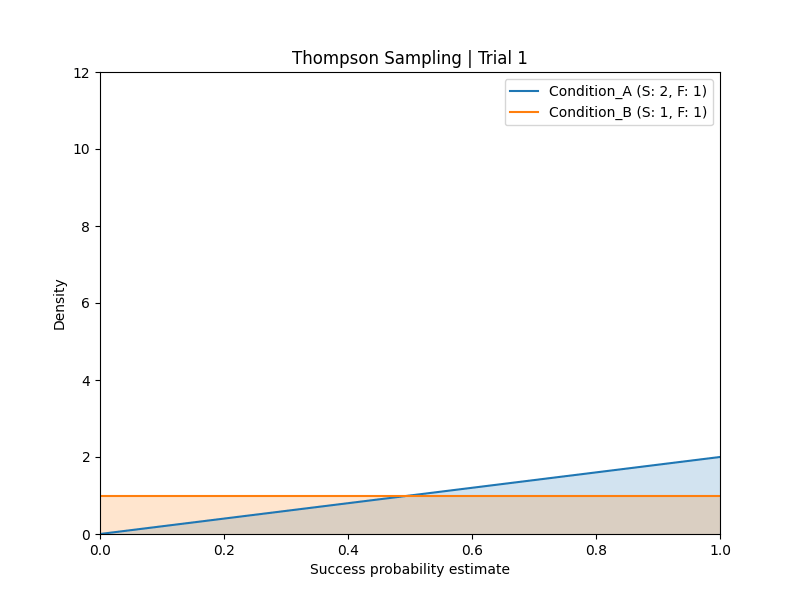

In [ ]:
from IPython.display import Image, display

# Display the GIF in the notebook
display(Image("Thompson_Sampling_Two_Conditions_Equal.gif"))

| run | condition assignment #1 | condition assignment #2
| 1. |


In [ ]:
import random
from scipy.stats import beta

def generate_synthetic_data(N):
    """
    Generates and prints synthetic A/B testing data using Thompson Sampling
    with two columns: condition and outcome.

    Args:
        N (int): Number of trials to simulate
    """
    # Initialize conditions with Beta(1,1) priors
    conditions = {
        "control": {"successes": 1, "failures": 1},
        "experimental": {"successes": 1, "failures": 1}
    }

    # True success rates (unknown to the algorithm)
    true_rates = {
        "control": 0.5,       # Control group success rate
        "experimental": 0.65   # Experimental group success rate
    }

    # Print header
    print("condition,outcome")

    for _ in range(N):
        # Thompson sampling to select condition
        sampled_control = beta.rvs(conditions["control"]["successes"],
                                  conditions["control"]["failures"])
        sampled_experimental = beta.rvs(conditions["experimental"]["successes"],
                                       conditions["experimental"]["failures"])

        chosen = "experimental" if sampled_experimental > sampled_control else "control"

        # Simulate outcome
        success = random.random() < true_rates[chosen]
        outcome = 1 if success else 0

        # Update posterior
        if success:
            conditions[chosen]["successes"] += 1
        else:
            conditions[chosen]["failures"] += 1

        # Print to console
        print(f"{chosen},{outcome}")

# Example usage:
generate_synthetic_data(100)

condition,outcome
experimental,0
control,0
experimental,1
experimental,1
control,0
experimental,1
experimental,0
experimental,1
experimental,0
experimental,1
experimental,1
experimental,0
experimental,1
experimental,1
experimental,1
experimental,0
experimental,1
experimental,1
experimental,1
experimental,1
experimental,1
experimental,1
experimental,0
control,0
experimental,1
experimental,1
experimental,1
experimental,1
experimental,1
experimental,1
experimental,1
experimental,0
experimental,1
experimental,1
experimental,0
experimental,1
experimental,1
experimental,1
experimental,0
experimental,1
experimental,1
experimental,0
experimental,0
experimental,0
experimental,0
experimental,1
experimental,0
experimental,0
experimental,0
experimental,0
experimental,1
experimental,0
experimental,0
experimental,1
experimental,0
experimental,1
experimental,1
experimental,1
experimental,1
experimental,1
experimental,1
experimental,1
experimental,1
experimental,0
experimental,0
experimental,0
experim

## Key concepts
https://en.wikipedia.org/wiki/Bernoulli_trial: A Bernoulli trial (or binomial trial) is a random experiment with exactly two possible outcomes, "success" and "failure", in which the probability of success is the same every time the experiment is conducted.

# Reference
* https://medium.com/@ark.iitkgp/thompson-sampling-python-implementation-cb35a749b7aa
* https://www.youtube.com/watch?v=1k8lF3BriXM
* https://www.youtube.com/watch?v=Zgwfw3bzSmQ
* https://www.youtube.com/watch?v=D8bofQKCUls
* https://www.youtube.com/watch?v=nkyDGGQ5h60
* https://www.youtube.com/watch?v=juF3r12nM5A
* https://en.wikipedia.org/wiki/Thompson_sampling
* https://github.com/kfoofw/bandit_simulations/blob/master/python/multiarmed_bandits/analysis/ts.md

In [ ]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Set parameters
true_success_rates = [0.449, 0.301]  # Code Execution (A) and Debugger (B)
alpha_prior, beta_prior = 1, 1  # Beta(1,1) prior for TS
n_simulations = 10000  # Number of Thompson Sampling simulations per sample size
max_students = 500  # Maximum sample size to test

# Store results
students_needed = []

# Loop over increasing sample sizes
for n_students in range(50, max_students + 1, 10):
    successes = [0, 0]  # Track successes for A and B
    failures = [0, 0]  # Track failures for A and B

    for _ in range(n_simulations):
        # Sample from posterior Beta distributions for each condition
        sampled_theta = [np.random.beta(successes[i] + alpha_prior, failures[i] + beta_prior) for i in range(2)]
        chosen_arm = np.argmax(sampled_theta)  # Pick best arm

        # Simulate outcome (Bernoulli trial) based on true success rates
        outcome = np.random.rand() < true_success_rates[chosen_arm]
        if outcome:
            successes[chosen_arm] += 1
        else:
            failures[chosen_arm] += 1

    # Check if Thompson Sampling reliably selects Code Execution (A) as the better condition
    best_arm_selected = np.argmax([successes[i] / (successes[i] + failures[i] + 1e-9) for i in range(2)])
    if best_arm_selected == 0:  # If Code Execution is correctly identified as superior
        students_needed.append(n_students)
        break

# Display results
result_df = {"Minimum Students Needed for TS to Detect Effect": [students_needed[0] if students_needed else "N/A"]}
result_df

{'Minimum Students Needed for TS to Detect Effect': [50]}

### **Step-by-Step Breakdown**
---
### **1. Initial Uncertainty (Random Choice)**
```python
sampled_theta = [np.random.beta(successes[i] + alpha_prior, failures[i] + beta_prior) for i in range(2)]
chosen_arm = np.argmax(sampled_theta)  # Pick best arm
```
- **`np.random.beta(...)` samples from the Beta distribution** for both tools (Code Execution & Debugger).  
  - At the **beginning**, since both tools have the **same prior (Beta(1,1))**, the samples are close, so selection is almost random.
- **`np.argmax(sampled_theta)` selects the tool with the higher sampled probability** (which is effectively a random choice early on).  
  - **This models the idea of trying both tools initially**, since their success rates are uncertain.

---
### **2. Gathering Evidence**
```python
outcome = np.random.rand() < true_success_rates[chosen_arm]
if outcome:
    successes[chosen_arm] += 1
else:
    failures[chosen_arm] += 1
```
- We **simulate whether the selected tool was successful** using the **true success rate**.
- If successful, we **increase its success count**; otherwise, we increase its failure count.
- Over time, **the tool with the higher true success rate will accumulate more successes**.

---
### **3. Learning Over Time (Exploitation vs. Exploration)**
```python
sampled_theta = [np.random.beta(successes[i] + alpha_prior, failures[i] + beta_prior) for i in range(2)]
chosen_arm = np.argmax(sampled_theta)
```
- Each round, we **re-sample from the updated Beta distributions**.  
  - If one tool has **higher accumulated successes**, its **posterior Beta distribution shifts** to favor higher sampled values.
- **TS naturally shifts toward choosing the better tool more often**, but still explores the other tool **occasionally** (exploration).

---
### **4. Stopping Condition: Deciding the Winner**
```python
best_arm_selected = np.argmax([successes[i] / (successes[i] + failures[i] + 1e-9) for i in range(2)])
if best_arm_selected == 0:  # If Code Execution is correctly identified as superior
    students_needed.append(n_students)
    break
```
- Here, we compute the **observed success rates** for both tools.
- If **Code Execution (Tool A) has the highest observed success rate**, we **declare it the winner and stop**.
- The first `n_students` that satisfies this condition is recorded as the **minimum sample size needed** for TS to make a confident decision.

---
### **Summary**
| Step | Code Snippet | What It Does |
|------|-------------|-------------|
| **1. Initial Uncertainty** | `sampled_theta = np.random.beta(...)` | Randomly picks a tool early on. |
| **2. Gathering Evidence** | `outcome = np.random.rand() < true_success_rates[chosen_arm]` | Simulates students trying the tools and recording success/failure. |
| **3. Learning Over Time** | `chosen_arm = np.argmax(sampled_theta)` | Over time, TS favors the better tool but still explores. |
| **4. Stopping Condition** | `if best_arm_selected == 0:` | Stops once Code Execution is clearly superior. |

---
**Initially, TS doesn’t know which tool is better, so it chooses randomly**.  
Then, **as students provide more data**, TS **updates its belief** and starts picking the better tool more often.  
Once TS **has enough confidence**, it stops and records the sample size.

